/home/mca/anaconda3/lib/python3.11/site-packages/torch/autograd/graph.py:865: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 11080). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch 0: Loss = 0.03397708386182785
Epoch 20: Loss = 0.018837159499526024
Epoch 40: Loss = 0.01595102623105049
Epoch 60: Loss = 0.014048819430172443
Epoch 80: Loss = 0.014136206358671188
Epoch 100: Loss = 0.018107714131474495
Epoch 120: Loss = 0.012059256434440613
Epoch 140: Loss = 0.006727112922817469
Epoch 160: Loss = 0.0031649365555495024
Epoch 180: Loss = 0.0009536079596728086


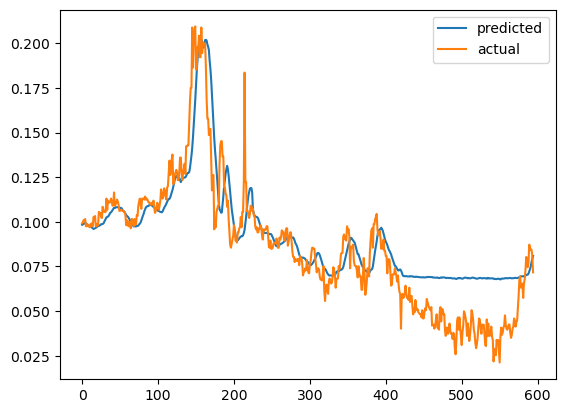

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split

# Load + preprocess
df = pd.read_csv("./daily.csv").dropna()
y = df['Price'].values

minm, maxm = y.min(), y.max()
y = (y - minm) / (maxm - minm)

Sequence_Length = 10

X, Y = [], []
for i in range(len(y) - Sequence_Length - 1):
    X.append(y[i:i+Sequence_Length])
    Y.append(y[i+Sequence_Length])

X, Y = np.array(X), np.array(Y)

# Split
x_train, x_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.1, shuffle=False
)

# Dataset (reuse later)
class NGTimeSeries(Dataset):
    def __init__(self, x, y):
        self.x = torch.tensor(x, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]

train_loader = DataLoader(NGTimeSeries(x_train, y_train), batch_size=256, shuffle=True)
test_dataset = NGTimeSeries(x_test, y_test)

# Model
class LSTMModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=1,
            hidden_size=5,
            batch_first=True
        )
        self.fc = nn.Linear(5, 1)

    def forward(self, x):
        out, (hn, cn) = self.lstm(x)
        out = out[:, -1, :]   # last time step
        return self.fc(torch.relu(out))

model = LSTMModel()

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# Training
epochs = 200

for epoch in range(epochs):
    model.train()
    for xb, yb in train_loader:
        xb = xb.view(-1, Sequence_Length, 1)

        optimizer.zero_grad()
        preds = model(xb).view(-1)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()

    if epoch % 20 == 0:
        print(f"Epoch {epoch}: Loss = {loss.item()}")

# Evaluation
model.eval()
with torch.no_grad():
    test_pred = model(test_dataset.x.view(-1, 10, 1)).view(-1)

plt.plot(test_pred.numpy(), label='predicted')
plt.plot(test_dataset.y.numpy(), label='actual')
plt.legend()
plt.show()

In [2]:
# Q2: Language Classification using RNN

import os
import string

all_letters = string.ascii_letters + " .,;'"
n_letters = len(all_letters)

def line_to_tensor(line):
    tensor = torch.zeros(len(line), 1, n_letters)
    for i, letter in enumerate(line):
        tensor[i][0][all_letters.find(letter)] = 1
    return tensor

# Load dataset
data_path = "./data/names"  # extracted from pytorch tutorial zip

category_lines = {}
all_categories = []

for filename in os.listdir(data_path):
    category = filename.split('.')[0]
    all_categories.append(category)
    with open(os.path.join(data_path, filename), encoding='utf-8') as f:
        category_lines[category] = f.read().strip().split('\n')

n_categories = len(all_categories)

# Model
class NameLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.hidden_size = hidden_size
        
        self.lstm = nn.LSTM(input_size, hidden_size)
        self.fc = nn.Linear(hidden_size, output_size)
        self.softmax = nn.LogSoftmax(dim=1)

    def forward(self, input, hidden):
        output, hidden = self.lstm(input, hidden)
        output = self.fc(output[-1])   # last timestep
        return self.softmax(output), hidden

    def init_hidden(self):
        # LSTM needs BOTH hidden state and cell state
        return (
            torch.zeros(1, 1, self.hidden_size),  # h0
            torch.zeros(1, 1, self.hidden_size)   # c0
        )

model2 = NameLSTM(n_letters, 128, n_categories)

criterion2 = nn.NLLLoss()

def category_from_output(output):
    return all_categories[output.argmax().item()]

# Training (minimal version)
import random

def random_training_example():
    category = random.choice(all_categories)
    line = random.choice(category_lines[category])
    return category, line, torch.tensor([all_categories.index(category)])

for i in range(1000):
    category, line, category_tensor = random_training_example()
    line_tensor = line_to_tensor(line)

    hidden = model2.init_hidden()
    model2.zero_grad()

    output, hidden = model2(line_tensor, hidden)
    loss = criterion2(output, category_tensor)

    loss.backward()

    for p in model2.parameters():
        p.data.add_(p.grad.data, alpha=-0.005)

    if i % 200 == 0:
        print(line, "->", category_from_output(output))

Sze  -> Korean
Isakov -> Vietnamese
Veen -> Italian
O'Hanlon -> Greek
Di antonio -> Chinese


In [3]:
# Q3: Next Character Prediction

class CharLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.hidden_size = hidden_size
        
        self.lstm = nn.LSTM(input_size, hidden_size)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, input, hidden):
        output, hidden = self.lstm(input, hidden)
        output = self.fc(output)
        return output, hidden

    def init_hidden(self):
        return (
            torch.zeros(1, 1, self.hidden_size),  # h0
            torch.zeros(1, 1, self.hidden_size)   # c0
        )

model3 = CharLSTM(n_letters, 128, n_letters)
criterion3 = nn.CrossEntropyLoss()
optimizer3 = torch.optim.Adam(model3.parameters(), lr=0.003)

# Simple training string
text = "hello world"

def text_to_tensors(text):
    inputs = line_to_tensor(text[:-1])
    targets = torch.tensor([all_letters.find(c) for c in text[1:]])
    return inputs, targets

inputs, targets = text_to_tensors(text)

# Training
for epoch in range(300):
    hidden = model3.init_hidden()
    optimizer3.zero_grad()

    output, hidden = model3(inputs, hidden)

    loss = 0
    for i in range(len(targets)):
        loss += criterion3(output[i], targets[i].unsqueeze(0))

    loss.backward()
    optimizer3.step()

    if epoch % 50 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item()}")

# Prediction
with torch.no_grad():
    hidden = model3.init_hidden()
    inp = line_to_tensor("hell")

    output, hidden = model3(inp, hidden)
    pred = output[-1].argmax().item()

    print("Next char:", all_letters[pred])

Epoch 0, Loss: 40.68095397949219
Epoch 50, Loss: 10.123512268066406
Epoch 100, Loss: 1.2092607021331787
Epoch 150, Loss: 0.1594856083393097
Epoch 200, Loss: 0.07936184108257294
Epoch 250, Loss: 0.05035868659615517
Next char: o
